# 01 — Classical GAN Baseline (multi-asset)

**ZHAW CEC Quantum Computing — Final project**

Trains a small classical GAN on log-return windows of multiple assets jointly (default: SMI + DAX). Choose vanilla GAN or WGAN-GP via `MODEL_VARIANT`. Choose univariate or multivariate via `TICKERS`.

Output: results saved to `results/classical_<variant>_<assets>/` for later head-to-head with the quantum GAN.

## Setup (Colab)

In [16]:
import os
if not os.path.isdir('/content/qGAN-market-generator'):
    !git clone https://github.com/wuns/qGAN-market-generator.git
%cd /content/qGAN-market-generator
!pip install -q yfinance pennylane

/content/qGAN-market-generator


In [17]:
import sys, pathlib, json
ROOT = pathlib.Path.cwd()
if (ROOT / 'src').is_dir():
    sys.path.insert(0, str(ROOT))
elif (ROOT.parent / 'src').is_dir():
    sys.path.insert(0, str(ROOT.parent))
    ROOT = ROOT.parent

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.data       import prepare_smi_data
from src.models     import ClassicalGenerator, Discriminator, Critic, count_parameters
from src.training   import set_seed, make_dataloader, build_experiment, generate
from src.evaluation import (plot_distributions, plot_acf_comparison, plot_sample_paths,
                            plot_correlation_comparison, build_report)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device =', device, '| repo root =', ROOT)

device = cpu | repo root = /content/qGAN-market-generator


## Config

**Two switches.** `TICKERS` controls assets (single string = univariate, list = multivariate). `MODEL_VARIANT` controls loss type.

In [18]:
TICKERS       = ['^SSMI', '^GDAXI', '^STOXX50E', '^FTSE', '^GSPC']    # SMI + DAX. Use '^SSMI' alone for univariate.
MODEL_VARIANT = 'gan'              # 'gan' (classical GAN) or 'wgan_gp' (Wasserstein GAN)

SEED       = 42
WINDOW     = 20
LATENT_DIM = 8
EPOCHS     = 80
BATCH      = 64

set_seed(SEED)

## Data

In [19]:
data = prepare_smi_data(
    tickers=TICKERS,
    window=WINDOW,
    cache_path=ROOT / 'results' / f"prices_{'_'.join(t.replace('^','') for t in (TICKERS if isinstance(TICKERS,list) else [TICKERS]))}.pkl",
)
print(f'Tickers:       {data.tickers}')
print(f'Train windows: {data.train_windows.shape}   (n_train, window, n_assets)')
print(f'Test  windows: {data.test_windows.shape}')
print(f'Per-asset scale (4 sigma): {data.scale}')
print(f'Date range: {data.dates[0].date()} to {data.dates[-1].date()}  ({len(data.dates)} days)')

Tickers:       ['^SSMI', '^GDAXI', '^STOXX50E', '^FTSE', '^GSPC']
Train windows: (3400, 20, 5)   (n_train, window, n_assets)
Test  windows: (836, 20, 5)
Per-asset scale (4 sigma): [0.04402781 0.05552749 0.05709574 0.0469102  0.05142152]
Date range: 2007-04-02 to 2024-12-30  (4274 days)


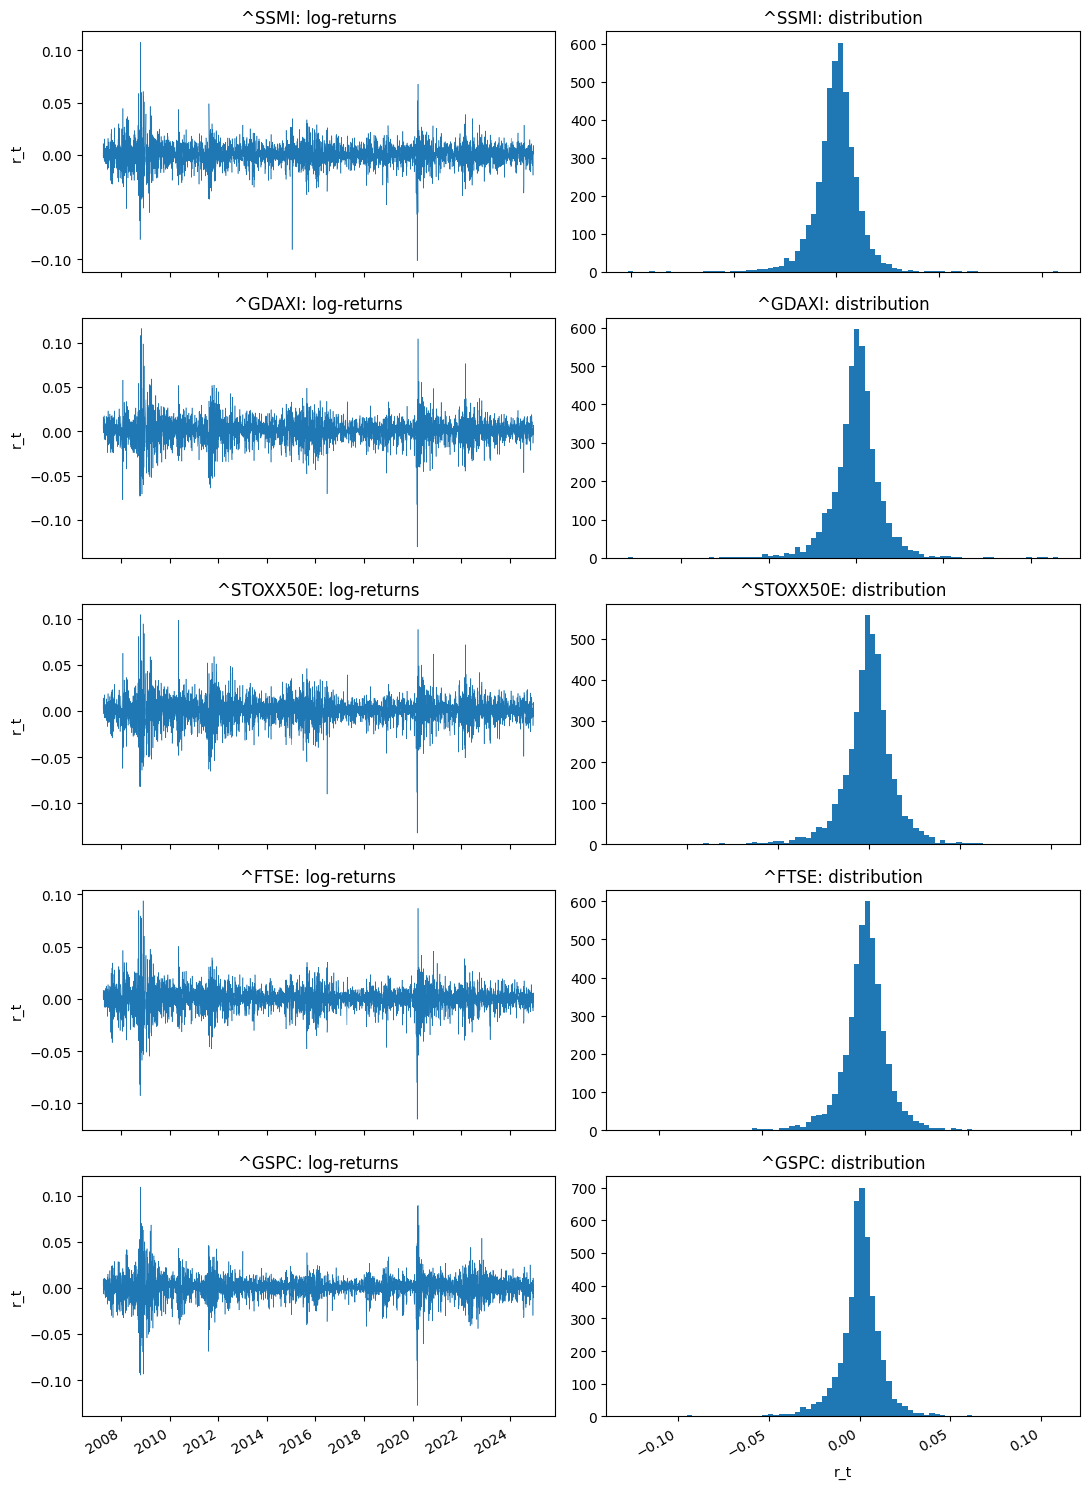

In [20]:
fig, ax = plt.subplots(data.n_assets, 2, figsize=(11, 3 * data.n_assets), squeeze=False)
for i, t in enumerate(data.tickers):
    ax[i, 0].plot(data.dates, data.raw_returns[:, i], lw=0.4)
    ax[i, 0].set_title(f'{t}: log-returns'); ax[i, 0].set_ylabel('r_t')
    ax[i, 1].hist(data.raw_returns[:, i], bins=80)
    ax[i, 1].set_title(f'{t}: distribution'); ax[i, 1].set_xlabel('r_t')
fig.autofmt_xdate()
plt.tight_layout(); plt.show()

## Model & training

Generator outputs `window * n_assets` flat values; data layer reshapes for evaluation. Discriminator/critic see flat windows — same architecture, same training loop, regardless of `n_assets`.

In [21]:
adversary_cls = Discriminator if MODEL_VARIANT == 'gan' else Critic

exp = build_experiment(
    variant=MODEL_VARIANT,
    latent_dim=LATENT_DIM,
    window=WINDOW,
    n_assets=data.n_assets,
    generator_cls=ClassicalGenerator,
    adversary_cls=adversary_cls,
)

n_params_G = count_parameters(exp.generator)
n_params_A = count_parameters(exp.adversary)
print(f'Variant:           {exp.label}')
print(f'n_assets:          {data.n_assets}  ({data.tickers})')
print(f'Generator params:  {n_params_G}')
print(f'{exp.adversary_role.capitalize():18s} params: {n_params_A}')

# Flatten windows for the GAN: (n, window, n_assets) -> (n, window*n_assets)
train_flat = data.flatten(data.train_windows)
loader = make_dataloader(train_flat, batch_size=BATCH)

history = exp.train_fn(
    exp.generator, exp.adversary, loader,
    latent_dim=LATENT_DIM, epochs=EPOCHS, device=device,
)
print(f'\nTraining time: {history.train_time_sec:.1f} s')

Variant:           vanilla GAN
n_assets:          5  (['^SSMI', '^GDAXI', '^STOXX50E', '^FTSE', '^GSPC'])
Generator params:  4644
Discriminator      params: 8577
  epoch  10/80  D=1.078  G=0.933
  epoch  20/80  D=0.822  G=1.317
  epoch  30/80  D=0.726  G=1.473
  epoch  40/80  D=0.710  G=1.608
  epoch  50/80  D=0.755  G=1.726
  epoch  60/80  D=0.975  G=1.427
  epoch  70/80  D=0.996  G=1.499
  epoch  80/80  D=0.735  G=1.772

Training time: 18.0 s


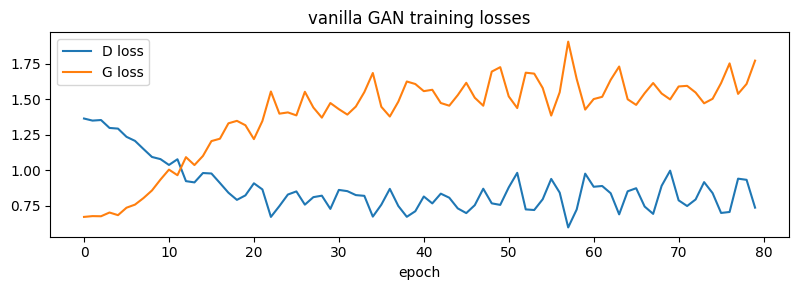

In [22]:
plt.figure(figsize=(8, 3))
d_label = 'D loss' if exp.adversary_role == 'discriminator' else 'C loss'
plt.plot(history.d_loss, label=d_label)
plt.plot(history.g_loss, label='G loss')
plt.xlabel('epoch'); plt.legend(); plt.title(f'{exp.label} training losses')
plt.tight_layout(); plt.show()

## Generate & evaluate

Generator outputs flat tensors → reshape to `(n, window, n_assets)` for evaluation.

In [23]:
n_eval = len(data.test_windows)
fake_flat_scaled, t_inf = generate(exp.generator, n_eval, LATENT_DIM, device=device)
fake_scaled = data.unflatten(fake_flat_scaled)              # (n, window, n_assets)
fake_returns = data.unscale(fake_scaled)
real_returns = data.unscale(data.test_windows)

samples_per_sec = (n_eval * WINDOW * data.n_assets) / t_inf
print(f'Inference: {n_eval} windows in {t_inf*1000:.1f} ms ({samples_per_sec:.0f} return-samples/s)')

Inference: 836 windows in 3.3 ms (25251607 return-samples/s)


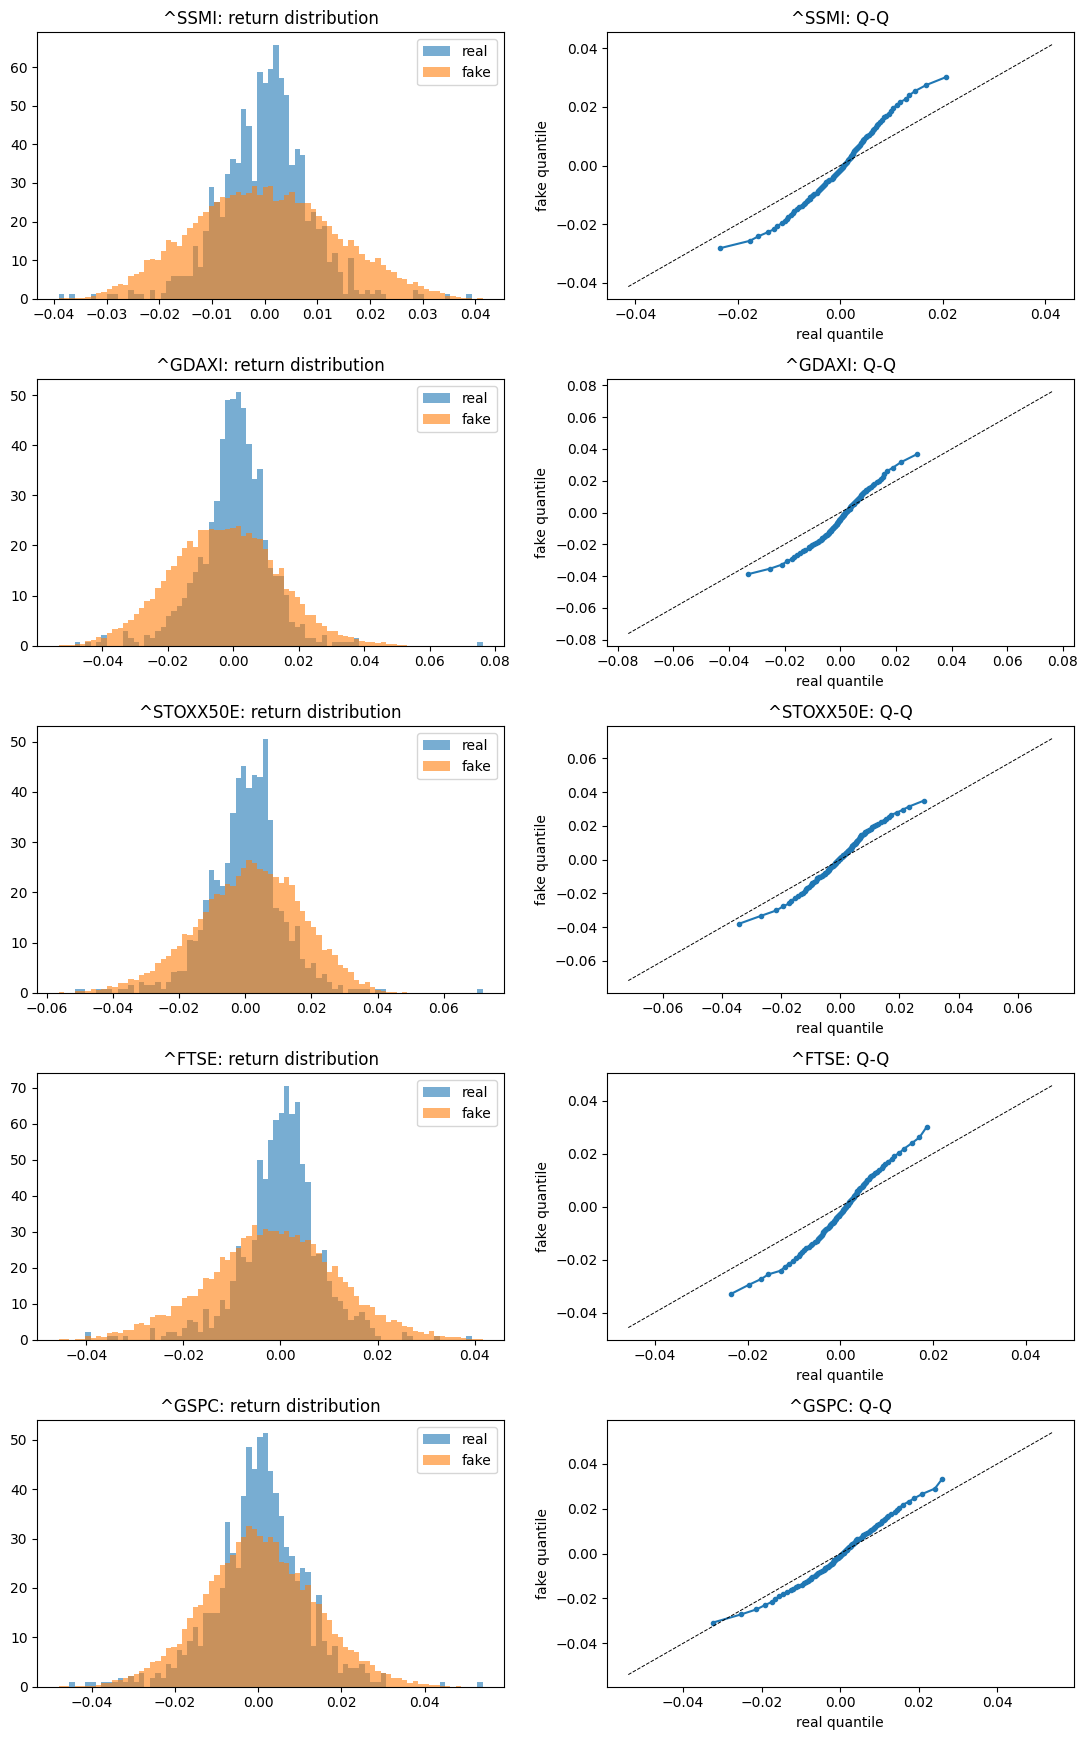

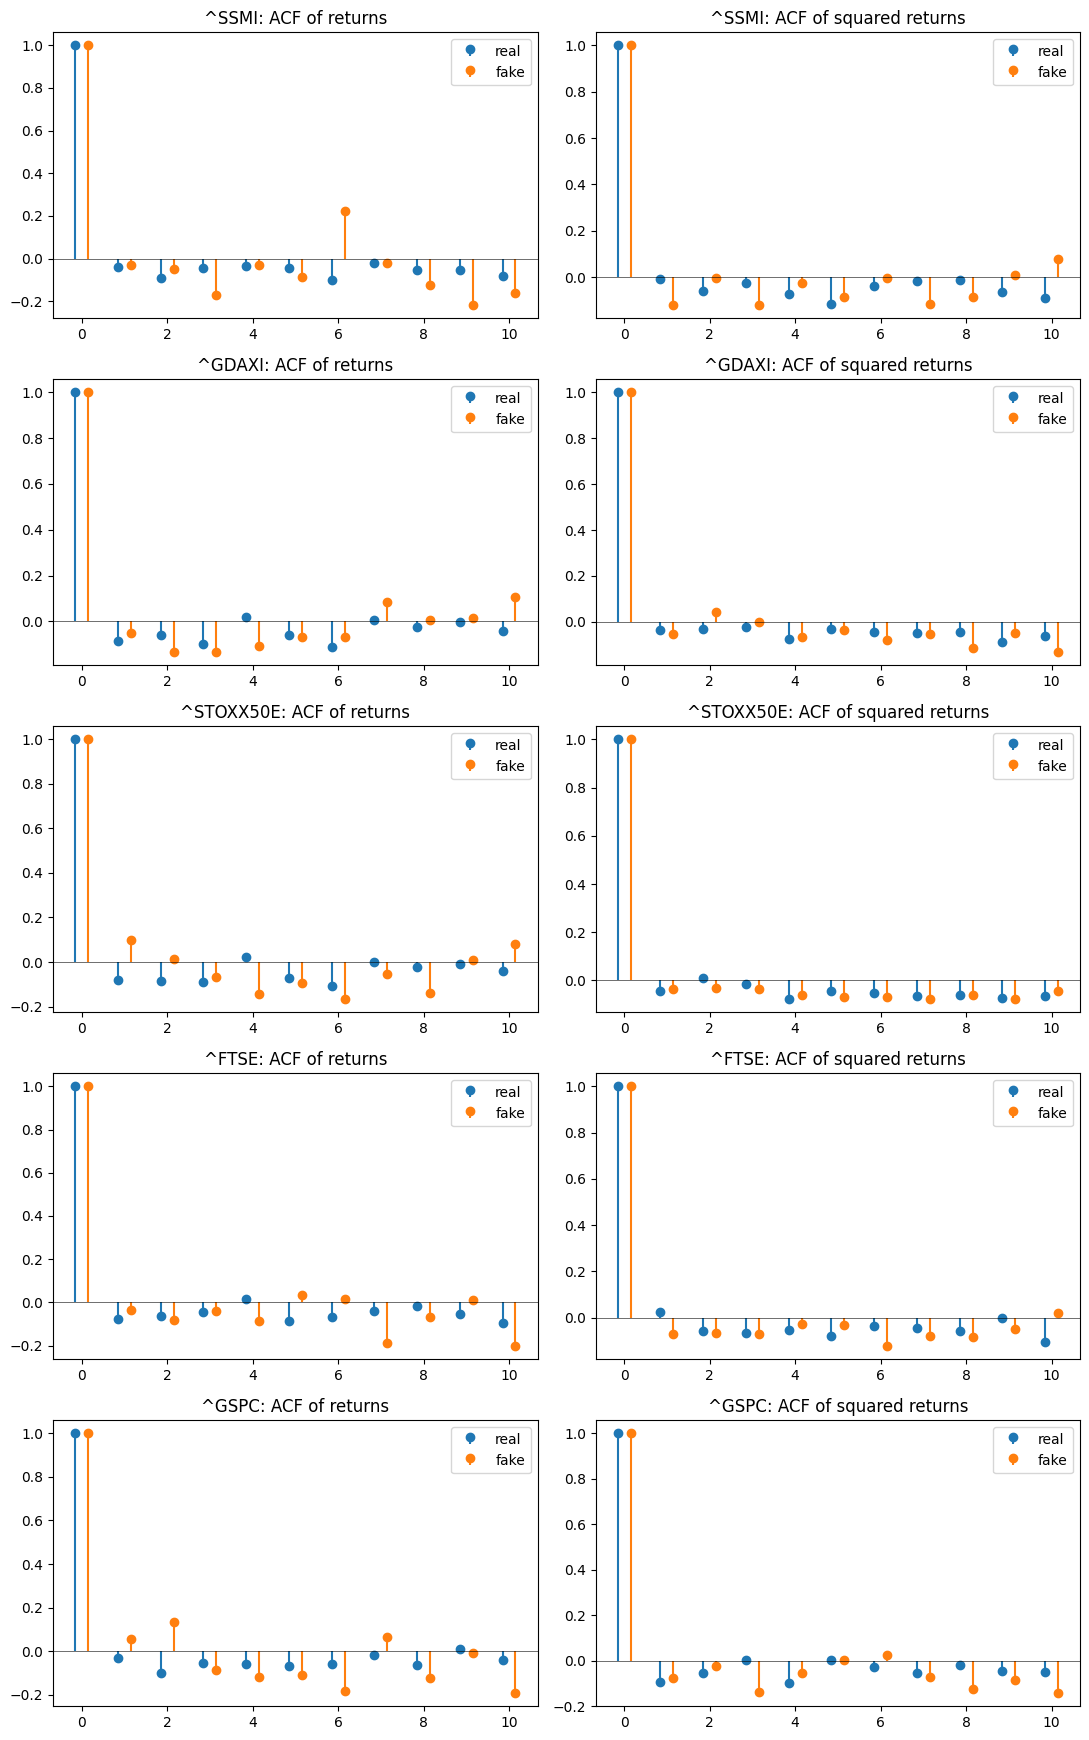

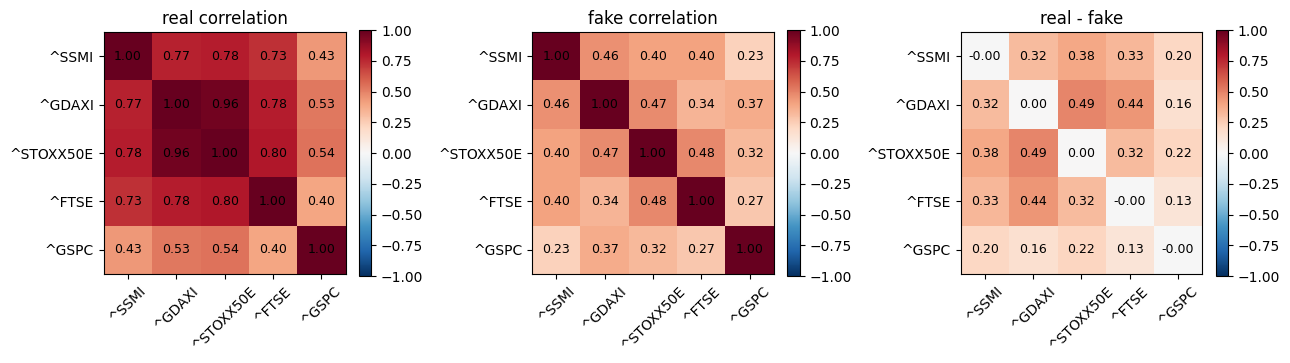

In [27]:
plot_distributions(real_returns, fake_returns, data.tickers); plt.tight_layout(); plt.show()
plot_acf_comparison(real_returns, fake_returns, data.tickers); plt.tight_layout(); plt.show()
if data.n_assets >= 2:
    plot_correlation_comparison(real_returns, fake_returns, data.tickers)
    plt.show()

In [25]:
report = build_report(
    real_windows=real_returns,
    fake_windows=fake_returns,
    tickers=data.tickers,
    n_params_G=n_params_G,
    n_params_D=n_params_A,
    train_time_sec=history.train_time_sec,
    inference_samples_per_sec=samples_per_sec,
    extras={'seed': SEED, 'epochs': EPOCHS, 'window': WINDOW,
            'latent_dim': LATENT_DIM, 'model': f'classical_{MODEL_VARIANT}'},
)

# Pretty-print the most relevant fields
print(f"=== {report['model']}  |  assets: {report['tickers']} ===\n")
for ticker in report['tickers']:
    r = report['real_per_asset'][ticker]
    f = report['fake_per_asset'][ticker]
    print(f'{ticker}:')
    print(f'  std       real={r["std"]:.5f}  fake={f["std"]:.5f}')
    print(f'  kurtosis  real={r["kurtosis"]:.3f}    fake={f["kurtosis"]:.3f}')
    print(f'  skew      real={r["skew"]:.3f}    fake={f["skew"]:.3f}')
print(f'\noverall KS:           {report["ks_statistic_overall"]:.4f}')
if 'correlation' in report:
    print(f'corr Frobenius err:   {report["correlation"]["frobenius_err"]:.4f}')
    print(f'real corr:\n  {np.array(report["correlation"]["real_corr"])}')
    print(f'fake corr:\n  {np.array(report["correlation"]["fake_corr"])}')
print(f'\ntraining time:        {report["training_time_sec"]} s')
print(f'generator params:     {report["n_params_generator"]}')

=== classical_gan  |  assets: ['^SSMI', '^GDAXI', '^STOXX50E', '^FTSE', '^GSPC'] ===

^SSMI:
  std       real=0.00832  fake=0.01334
  kurtosis  real=2.330    fake=-0.426
  skew      real=-0.153    fake=0.100
^GDAXI:
  std       real=0.01090  fake=0.01622
  kurtosis  real=4.466    fake=-0.095
  skew      real=-0.040    fake=0.086
^STOXX50E:
  std       real=0.01137  fake=0.01581
  kurtosis  real=3.655    fake=-0.092
  skew      real=-0.110    fake=-0.247
^FTSE:
  std       real=0.00815  fake=0.01327
  kurtosis  real=3.206    fake=0.004
  skew      real=-0.481    fake=-0.032
^GSPC:
  std       real=0.01091  fake=0.01341
  kurtosis  real=1.953    fake=0.035
  skew      real=-0.197    fake=0.083

overall KS:           0.1370
corr Frobenius err:   1.4346
real corr:
  [[1.         0.77322761 0.7847689  0.73373332 0.43467662]
 [0.77322761 1.         0.9647975  0.78390206 0.5303692 ]
 [0.7847689  0.9647975  1.         0.80026521 0.54101   ]
 [0.73373332 0.78390206 0.80026521 1.         0.39550

## Save artefacts

In [26]:
asset_tag = '_'.join(t.replace('^', '') for t in data.tickers)
out = ROOT / 'results' / f'classical_{MODEL_VARIANT}_{asset_tag}'
out.mkdir(parents=True, exist_ok=True)
torch.save(exp.generator.state_dict(), out / 'generator.pt')
np.save(out / 'fake_returns.npy', fake_returns)
np.save(out / 'real_returns_test.npy', real_returns)
np.save(out / 'scale.npy', data.scale)
with open(out / 'metrics.json', 'w') as f:
    json.dump(report, f, indent=2, default=float)
print('Saved to', out)

Saved to /content/qGAN-market-generator/results/classical_gan_SSMI_GDAXI_STOXX50E_FTSE_GSPC
